# 03 — Getting started: from `.mat` to vectors and PCA

This tutorial uses the real T15 interleaved session. It shows every important shape explicitly: loading the MATLAB file, selecting one trial, creating a 64-channel trial vector, averaging 22 repetitions into a word centroid, exporting CSV files, and fitting one shared PCA to all 14 `condition × word` centroids.

Run `python3 scripts/reproduce.py --data-only` before opening this notebook on a fresh clone.

## The complete data path

```text
T15 .mat file
    ↓ load_interleaved_mat()
dataset.rates: [trial, time, channel] = [308, 150, 64]
    ↓ choose 0–500 ms and average over time
one 64-value vector per trial
    ↓ average repetitions within condition + word
14 centroids: 7 words × 2 conditions, each with 64 values
    ↓ fit one PCA to the 14 × 64 matrix
14 points in a shared PC1/PC2 plot
```

PCA is **not** fitted separately for each word. All words and both conditions use the same axes, which is what makes their positions comparable.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run this notebook from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT / 'src'))

from kunz_speech_geometry.config import load_config
from kunz_speech_geometry.io import load_interleaved_mat
from kunz_speech_geometry.pca import fit_shared_pca, standardized_trial_vectors
from kunz_speech_geometry.preprocess import smooth_and_baseline, window_mask

CONFIG_PATH = ROOT / 'configs' / 't15_interleaved_binnedtx.yaml'
config = load_config(CONFIG_PATH)
MAT_PATH = ROOT / config['dataset']['mat_path']
if not MAT_PATH.is_file():
    raise FileNotFoundError(
        f'{MAT_PATH} is missing. Run: python3 scripts/reproduce.py --data-only'
    )

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})
print('Config:', CONFIG_PATH.relative_to(ROOT))
print('MAT file:', MAT_PATH.relative_to(ROOT))

Config: configs/t15_interleaved_binnedtx.yaml
MAT file: data/raw/interleavedVerbalBehaviors/t15.2024.06.14_interleavedVerbalBehaviors_raw.mat


## 1. Load the MATLAB file into a documented tensor

`load_interleaved_mat()` handles MATLAB's 1-based indexing, cue text, condition labels, channel sets, block IDs, and trial alignment. The result is a `NeuralDataset` whose required axis order is always `[trial, time, channel]`.

In [2]:
dataset_all = load_interleaved_mat(
    MAT_PATH,
    feature=config['dataset']['feature'],
    channel_sets=config['dataset']['channel_sets'],
    epoch_ms=tuple(config['dataset']['epoch_ms']),
    block_center=config['dataset']['block_center'],
)
dataset = dataset_all.subset_conditions(config['dataset']['conditions'])

print('dataset.rates shape [trial, time, channel]:', dataset.rates.shape)
print('dataset.time_ms shape:', dataset.time_ms.shape)
print('dataset.trials shape:', dataset.trials.shape)
print('dataset.channels shape:', dataset.channels.shape)
print('Feature:', dataset.feature_name, '| Units:', dataset.units)

dataset.rates shape [trial, time, channel]: (308, 150, 64)
dataset.time_ms shape: (150,)
dataset.trials shape: (308, 9)
dataset.channels shape: (64, 3)
Feature: binnedTX_block_centered | Units: counts/bin


In [3]:
trial_columns = ['trial_id', 'condition', 'word', 'block', 'alignment_event_raw']
display(dataset.trials[trial_columns].head(10))

counts = (
    dataset.trials.groupby(['condition', 'word'])
    .size()
    .rename('n_trials')
    .unstack(fill_value=0)
)
display(counts)

,trial_id,condition,word,block,alignment_event_raw
0,t15.2024.06.14_trial_0000,attempted_vocalized,were,3,go_start
1,t15.2024.06.14_trial_0003,attempted_vocalized,ban,3,go_start
2,t15.2024.06.14_trial_0009,passive_listening,feel,3,go_start
3,t15.2024.06.14_trial_0012,attempted_vocalized,kite,3,go_start
4,t15.2024.06.14_trial_0014,passive_listening,ban,3,go_start
5,t15.2024.06.14_trial_0015,attempted_vocalized,ban,3,go_start
6,t15.2024.06.14_trial_0021,passive_listening,day,3,go_start
7,t15.2024.06.14_trial_0022,passive_listening,kite,3,go_start
8,t15.2024.06.14_trial_0025,passive_listening,were,3,go_start
9,t15.2024.06.14_trial_0027,attempted_vocalized,kite,3,go_start


word,ban,choice,day,feel,kite,though,were
condition,,,,,,,
attempted_vocalized,22,22,22,22,22,22,22
passive_listening,22,22,22,22,22,22,22


The table confirms 22 repetitions for every word in each condition. Trial metadata and neural rows have the same order, so row `i` in `dataset.trials` describes `dataset.rates[i]`.

## 2. Select one word, one condition, and one trial

Change `WORD` or `CONDITION` to explore a different cell. We begin with the first attempted-vocalized trial for `ban`.

In [4]:
WORD = 'ban'
CONDITION = 'attempted_vocalized'

matching_indices = np.flatnonzero(
    (dataset.trials['word'].to_numpy() == WORD)
    & (dataset.trials['condition'].to_numpy() == CONDITION)
)
trial_index = int(matching_indices[0])
one_trial = dataset.rates[trial_index]

display(dataset.trials.loc[[trial_index], trial_columns])
print('Number of matching trials:', matching_indices.size)
print('One trial shape [time, channel]:', one_trial.shape)

,trial_id,condition,word,block,alignment_event_raw
1,t15.2024.06.14_trial_0003,attempted_vocalized,ban,3,go_start


Number of matching trials: 22
One trial shape [time, channel]: (150, 64)


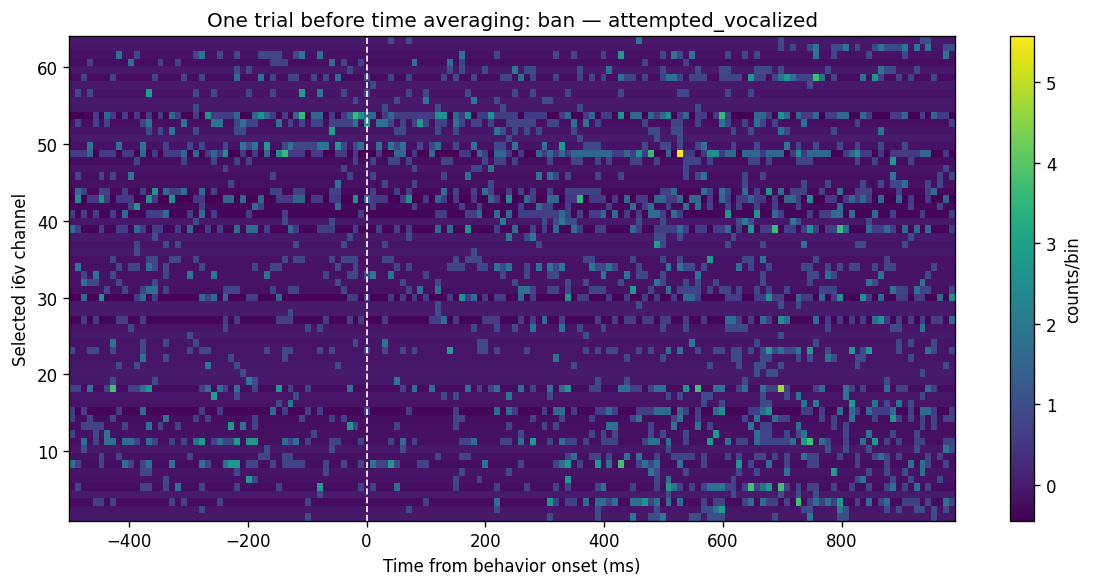

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(
    one_trial.T,
    aspect='auto',
    origin='lower',
    extent=[dataset.time_ms[0], dataset.time_ms[-1], 1, one_trial.shape[1]],
    cmap='viridis',
)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.set(
    xlabel='Time from behavior onset (ms)',
    ylabel='Selected i6v channel',
    title=f'One trial before time averaging: {WORD} — {CONDITION}',
)
fig.colorbar(image, ax=ax, label=dataset.units)
fig.tight_layout()
plt.show()

## 3. Turn the trial's response window into one 64-value vector

We first apply the same smoothing and per-trial baseline subtraction used by Notebook 02. Then we select the configured response window and average over its time axis.

A timing detail is made explicit below: the project's current `window_mask()` includes both endpoints, so `[0, 500]` selects the samples at 0, 10, …, 500 ms (51 samples). A strictly half-open 500 ms interval, `0 ≤ t < 500`, would contain 50 samples. The tutorial preserves the inclusive mask so its exported vectors exactly match the current README analysis.

In [6]:
pre = config['preprocessing']
processed = smooth_and_baseline(
    dataset,
    smoothing_sigma_ms=pre['smoothing_sigma_ms'],
    baseline_window_ms=pre['baseline_window_ms'],
    baseline_correct=pre['baseline_correct'],
)
analysis_mask = window_mask(processed.time_ms, pre['analysis_window_ms'])
half_open_mask = (processed.time_ms >= 0) & (processed.time_ms < 500)

one_response_window = processed.rates[trial_index, analysis_mask, :]
one_trial_vector_unscaled = one_response_window.mean(axis=0)

print('Configured inclusive window samples:', int(analysis_mask.sum()))
print('Half-open 0 <= t < 500 samples:', int(half_open_mask.sum()))
print('Selected response window shape [time, channel]:', one_response_window.shape)
print('Trial vector shape [channel]:', one_trial_vector_unscaled.shape)

Configured inclusive window samples: 51
Half-open 0 <= t < 500 samples: 50
Selected response window shape [time, channel]: (51, 64)
Trial vector shape [channel]: (64,)


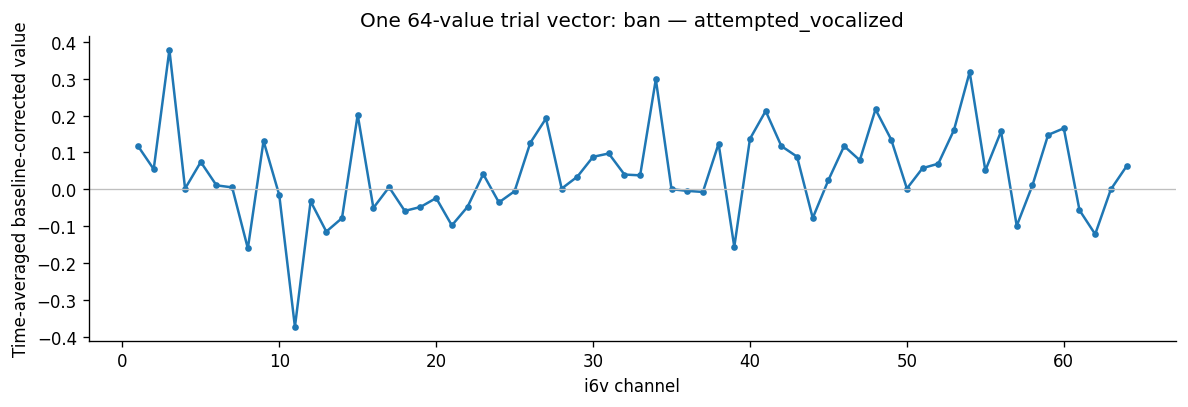

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(np.arange(1, 65), one_trial_vector_unscaled, marker='o', markersize=3)
ax.axhline(0, color='0.75', linewidth=0.8)
ax.set(
    xlabel='i6v channel',
    ylabel='Time-averaged baseline-corrected value',
    title=f'One 64-value trial vector: {WORD} — {CONDITION}',
)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Turn 22 trial vectors into one word-condition centroid

Each of the 22 matching trials becomes a row with 64 channel values. Their row-wise mean is the centroid for `ban — attempted_vocalized`.

In [8]:
matching_windows = processed.rates[matching_indices][:, analysis_mask, :]
matching_trial_vectors_unscaled = matching_windows.mean(axis=1)
word_condition_centroid_unscaled = matching_trial_vectors_unscaled.mean(axis=0)

print('All matching response windows [trial, time, channel]:', matching_windows.shape)
print('All matching trial vectors [trial, channel]:', matching_trial_vectors_unscaled.shape)
print('One word-condition centroid [channel]:', word_condition_centroid_unscaled.shape)

All matching response windows [trial, time, channel]: (22, 51, 64)
All matching trial vectors [trial, channel]: (22, 64)
One word-condition centroid [channel]: (64,)


## 5. Build and export vectors for all 308 trials

For the PCA analysis, every channel is standardized with one scaler fitted to pooled observations from both conditions. It is not fitted separately by word or condition. The formula is shown directly and checked against the reusable project function.

In [9]:
labels = processed.trials['condition'].to_numpy()
shared = fit_shared_pca(
    processed.rates,
    labels,
    n_components=config['pca']['n_components'],
    fit_time_mask=analysis_mask,
    balance_conditions=config['pca']['balance_conditions_for_fit'],
    standardize_channels=pre['standardize_channels'],
    random_state=config['project']['random_seed'],
)

all_trial_vectors_unscaled = processed.rates[:, analysis_mask, :].mean(axis=1)
all_trial_vectors = (
    all_trial_vectors_unscaled - shared.scaler_mean
) / shared.scaler_scale

helper_vectors = standardized_trial_vectors(processed.rates, analysis_mask, shared)
assert np.allclose(all_trial_vectors, helper_vectors)

print('Unscaled trial-vector matrix:', all_trial_vectors_unscaled.shape)
print('Pooled-standardized trial-vector matrix:', all_trial_vectors.shape)
print('Manual formula matches standardized_trial_vectors():', True)

Unscaled trial-vector matrix: (308, 64)
Pooled-standardized trial-vector matrix: (308, 64)
Manual formula matches standardized_trial_vectors(): True


In [10]:
EXPORT_DIR = ROOT / 'results' / 'tables' / 'tutorial_vectors'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
channel_columns = processed.channels['channel_id'].tolist()
metadata_columns = ['participant', 'session', 'block', 'trial_id', 'condition', 'word']

trial_vectors_table = pd.concat(
    [
        processed.trials[metadata_columns].reset_index(drop=True),
        pd.DataFrame(all_trial_vectors, columns=channel_columns),
    ],
    axis=1,
)
trial_vectors_table.insert(len(metadata_columns), 'vector_space', 'pooled_standardized')

word_centroids_table = (
    trial_vectors_table.groupby(['condition', 'word'], as_index=False)[channel_columns]
    .mean()
)
word_centroids_table.insert(2, 'n_trials', 22)
word_centroids_table.insert(3, 'vector_space', 'pooled_standardized')

trial_path = EXPORT_DIR / 'trial_vectors.csv'
centroid_path = EXPORT_DIR / 'word_centroids.csv'
trial_vectors_table.to_csv(trial_path, index=False)
word_centroids_table.to_csv(centroid_path, index=False)

print('Saved:', trial_path.relative_to(ROOT), trial_vectors_table.shape)
print('Saved:', centroid_path.relative_to(ROOT), word_centroids_table.shape)
display(trial_vectors_table.head(3))
display(word_centroids_table[['condition', 'word', 'n_trials']])

Saved: results/tables/tutorial_vectors/trial_vectors.csv (308, 71)
Saved: results/tables/tutorial_vectors/word_centroids.csv (14, 68)


,participant,session,block,trial_id,condition,word,vector_space,ch001,ch002,ch003,...,ch055,ch056,ch057,ch058,ch059,ch060,ch061,ch062,ch063,ch064
0,T15,t15.2024.06.14,3,t15.2024.06.14_trial_0000,attempted_vocalized,were,pooled_standardized,1.043058,0.099980,0.229769,...,-0.916214,0.334237,-2.165099,-0.002605,0.715735,0.031028,0.520126,-0.215492,0.482432,0.066980
1,T15,t15.2024.06.14,3,t15.2024.06.14_trial_0003,attempted_vocalized,ban,pooled_standardized,2.036773,0.650931,1.728774,...,0.399232,1.828015,-0.646325,0.143519,0.226920,1.096924,-0.055752,-1.180939,0.090110,1.249671
2,T15,t15.2024.06.14,3,t15.2024.06.14_trial_0009,passive_listening,feel,pooled_standardized,-1.161798,0.042711,-0.051860,...,0.136241,0.395219,0.109846,1.034888,0.262183,-0.377784,1.547422,2.805511,0.640848,-0.149910


,condition,word,n_trials
0,attempted_vocalized,ban,22
1,attempted_vocalized,choice,22
2,attempted_vocalized,day,22
3,attempted_vocalized,feel,22
4,attempted_vocalized,kite,22
5,attempted_vocalized,though,22
6,attempted_vocalized,were,22
7,passive_listening,ban,22
8,passive_listening,choice,22
9,passive_listening,day,22


## 6. Fit one PCA to all 14 centroids

The PCA input has 14 rows and 64 columns. `fit_transform()` is called once on the entire matrix. PC1 and PC2 are therefore shared axes for every word and both conditions.

In [11]:
centroid_matrix = word_centroids_table[channel_columns].to_numpy()
pca = PCA(n_components=2, svd_solver='full')
centroid_scores = pca.fit_transform(centroid_matrix)

pca_table = word_centroids_table[['condition', 'word']].copy()
pca_table['PC1'] = centroid_scores[:, 0]
pca_table['PC2'] = centroid_scores[:, 1]

print('PCA input [condition-word centroid, channel]:', centroid_matrix.shape)
print('PCA output [condition-word centroid, PC]:', centroid_scores.shape)
print('PC1 explained variance:', f'{100 * pca.explained_variance_ratio_[0]:.1f}%')
print('PC2 explained variance:', f'{100 * pca.explained_variance_ratio_[1]:.1f}%')
display(pca_table)

PCA input [condition-word centroid, channel]: (14, 64)
PCA output [condition-word centroid, PC]: (14, 2)
PC1 explained variance: 51.5%
PC2 explained variance: 8.7%


,condition,word,PC1,PC2
0,attempted_vocalized,ban,1.521632,-0.263737
1,attempted_vocalized,choice,1.653243,-0.001206
2,attempted_vocalized,day,1.715005,-0.172772
3,attempted_vocalized,feel,0.962784,-0.420656
4,attempted_vocalized,kite,1.704630,-0.098317
5,attempted_vocalized,though,1.257048,0.861967
6,attempted_vocalized,were,1.229403,0.134219
7,passive_listening,ban,-1.442170,-0.345612
8,passive_listening,choice,-1.588844,-0.837484
9,passive_listening,day,-1.333771,0.063938


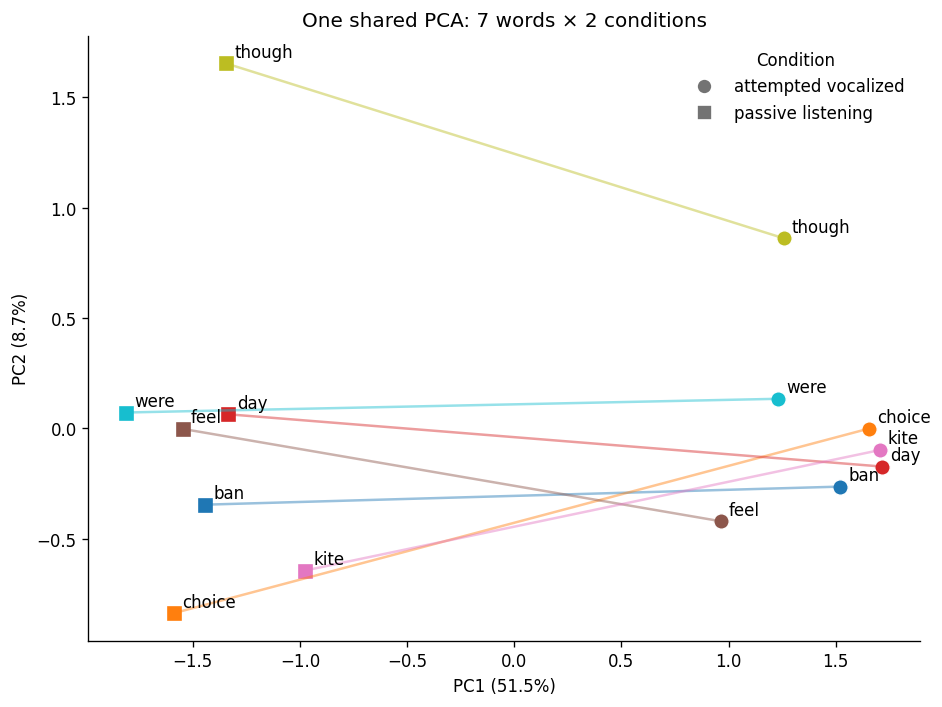

In [12]:
conditions = sorted(pca_table['condition'].unique())
words = sorted(pca_table['word'].unique())
markers = {conditions[0]: 'o', conditions[1]: 's'}
colors = dict(zip(words, plt.get_cmap('tab10')(np.linspace(0, 1, len(words)))))

fig, ax = plt.subplots(figsize=(8, 6))
for word in words:
    rows = pca_table.index[pca_table['word'] == word].to_numpy()
    ax.plot(
        pca_table.loc[rows, 'PC1'],
        pca_table.loc[rows, 'PC2'],
        color=colors[word],
        alpha=0.45,
    )
    for row in rows:
        condition = pca_table.loc[row, 'condition']
        ax.scatter(
            pca_table.loc[row, 'PC1'],
            pca_table.loc[row, 'PC2'],
            color=colors[word],
            marker=markers[condition],
            s=85,
            edgecolor='white',
            linewidth=0.8,
        )
        ax.annotate(
            word,
            (pca_table.loc[row, 'PC1'], pca_table.loc[row, 'PC2']),
            xytext=(5, 4),
            textcoords='offset points',
        )

legend_handles = [
    plt.Line2D(
        [0], [0], marker=markers[condition], color='none',
        markerfacecolor='0.45', markeredgecolor='white', markersize=9,
        label=condition.replace('_', ' '),
    )
    for condition in conditions
]
ax.set(
    xlabel=f'PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)',
    ylabel=f'PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)',
    title='One shared PCA: 7 words × 2 conditions',
)
ax.legend(handles=legend_handles, frameon=False, title='Condition')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## What the plot does—and does not—say

- Each point is one 64-value `condition × word` centroid projected onto shared PC1 and PC2.
- A line connects the same word across attempted speech and passive listening.
- PCA chooses directions with high variance; it is not told to separate the conditions.
- The two-dimensional plot is descriptive. The permutation p-value in Notebook 02 is calculated from whole trials in the full 64-channel standardized space, not from only PC1 and PC2.
- A channel value is a preprocessed neural feature, not a word embedding dimension with an intrinsic linguistic name.

To explore another cell, change `WORD` and `CONDITION` above. Available conditions are `attempted_vocalized` and `passive_listening`; available words are `ban`, `choice`, `day`, `feel`, `kite`, `though`, and `were`.